# Efficiency-Prize leaderboard: insights and where this project stands

**Reference:** the organisers' *RSNA Knee Abnormalities – Efficiency LB* notebook, which lists the top 100
teams of the Efficiency Prize track. Its `leaderboard.csv` input is on Kaggle and cannot be reached from this
environment. The table below was parsed from that notebook's saved output (top 100 rows, columns
`EfficiencyRank`, `TeamName`, `PublicScore`, `DateSubmitted`) into `data/efficiency_lb_top100.csv`.

**Not available:** the per-team runtime and the exact efficiency formula. Those live on the competition's
*Efficiency Prize Evaluation* page, which is also unreachable. Statements about runtime below are
therefore **inferences from rank order**, not measurements.

This project's numbers come from `results/summary.csv`. They were measured on held-out folds and on the
58 expert-labelled studies. They are **not** leaderboard scores, because nothing was submitted to Kaggle.

In [1]:
import pandas as pd, numpy as np, matplotlib.pyplot as plt
from scipy.stats import spearmanr

pd.options.display.min_rows = 100
pd.options.display.max_rows = 100

# reference cell, adapted: local copy of the leaderboard shown in the reference notebook
leaderboard = pd.read_csv('../data/efficiency_lb_top100.csv', index_col='EfficiencyRank')
leaderboard['DateSubmitted'] = pd.to_datetime(leaderboard['DateSubmitted'], format='%a %b %d %H:%M:%S %Y')
leaderboard.head(10)

,TeamName,PublicScore,DateSubmitted
EfficiencyRank,,,
1,Scott Willis,0.958,2026-09-24 15:50:36
2,Avinash Niroula,0.948,2026-09-22 20:40:23
3,Brandon Low,0.954,2026-09-22 07:11:01
4,tomoon33,0.954,2026-09-24 15:22:58
5,UCAS_fish_wang,0.951,2026-09-24 00:02:08
6,Lukas Nissen Molvær,0.955,2026-09-25 19:34:21
7,Claudio Verdú Ruiz,0.945,2026-09-23 09:29:11
8,Marco Ledda,0.944,2026-09-25 17:10:58
9,Cemal Ataş & Gülşah Ataş,0.945,2026-09-24 17:45:34


## 1. Score distribution of the top 100

In [2]:
s = leaderboard.PublicScore
summary = pd.Series({'teams': len(s), 'min': s.min(), 'q25': s.quantile(.25), 'median': s.median(),
                     'q75': s.quantile(.75), 'max': s.max(), 'range': s.max() - s.min()}).round(4)
summary

teams     100.0000
min         0.9160
q25         0.9318
median      0.9400
q75         0.9452
max         0.9580
range       0.0420
dtype: float64

## 2. Does efficiency rank follow accuracy?

In [3]:
rho, p = spearmanr(leaderboard.index, leaderboard.PublicScore)
best = leaderboard.PublicScore.idxmax()
print(f'Spearman(EfficiencyRank, PublicScore) = {rho:.3f} (p = {p:.3g})')
print(f'Highest public score in top-100: {leaderboard.PublicScore.max():.3f} at efficiency rank {best} '
      f'({leaderboard.loc[best, "TeamName"]})')
top10 = leaderboard.head(10).PublicScore
print(f'Top-10 efficiency ranks: public score {top10.min():.3f}-{top10.max():.3f}, mean {top10.mean():.4f}')

# rank inversions: team i ranked above team j despite a lower score => i must be cheaper to run
inv = [(i, j) for i in leaderboard.index for j in leaderboard.index
       if i < j and leaderboard.PublicScore[i] < leaderboard.PublicScore[j]]
print(f'Ordered pairs where the better-ranked team has the LOWER score: {len(inv)} of {100*99//2} '
      f'({len(inv)/(100*99/2):.0%}) -> runtime must be doing much of the ranking')

Spearman(EfficiencyRank, PublicScore) = -0.559 (p = 1.49e-09)
Highest public score in top-100: 0.958 at efficiency rank 1 (Scott Willis)
Top-10 efficiency ranks: public score 0.944-0.958, mean 0.9503
Ordered pairs where the better-ranked team has the LOWER score: 1418 of 4950 (29%) -> runtime must be doing much of the ranking


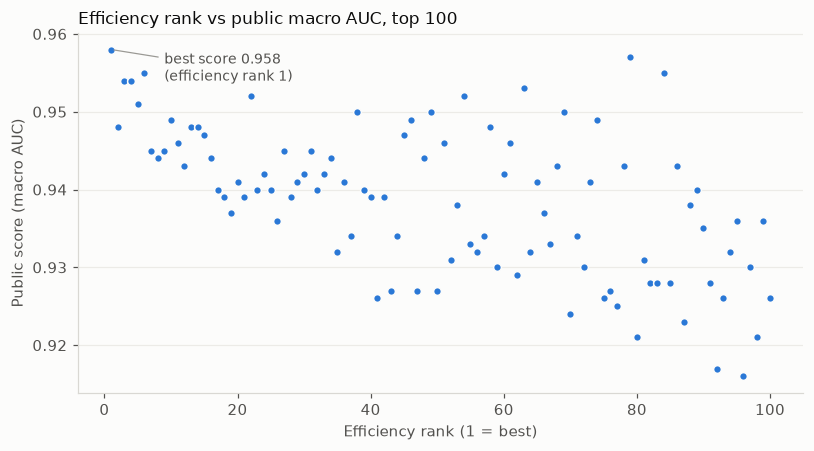

In [4]:
fig, ax = plt.subplots(figsize=(7.5, 4.2), dpi=110)
fig.patch.set_facecolor('#fcfcfb'); ax.set_facecolor('#fcfcfb')
ax.scatter(leaderboard.index, leaderboard.PublicScore, s=26, color='#2a78d6', edgecolor='#fcfcfb', linewidth=1)
b = leaderboard.PublicScore.idxmax()
ax.annotate(f'best score {leaderboard.PublicScore[b]:.3f}\n(efficiency rank {b})', (b, leaderboard.PublicScore[b]),
            xytext=(b + 8, leaderboard.PublicScore[b] - 0.004), fontsize=9, color='#52514e',
            arrowprops=dict(arrowstyle='-', color='#9a9994', lw=0.8))
ax.set_xlabel('Efficiency rank (1 = best)', color='#52514e'); ax.set_ylabel('Public score (macro AUC)', color='#52514e')
ax.set_title('Efficiency rank vs public macro AUC, top 100', loc='left', fontsize=11, color='#0b0b0b')
for sp in ['top', 'right']: ax.spines[sp].set_visible(False)
for sp in ['left', 'bottom']: ax.spines[sp].set_color('#d9d8d3')
ax.tick_params(colors='#52514e'); ax.grid(axis='y', color='#ecebe7', lw=0.8); ax.set_axisbelow(True)
plt.tight_layout(); plt.show()

## 3. When were the ranked submissions made?

In [5]:
d = leaderboard.DateSubmitted.dt.date.value_counts().sort_index()
print(d.to_string())
print(f'\n{(leaderboard.DateSubmitted >= "2026-09-20").mean():.0%} of top-100 selected submissions were made in the last week shown')

DateSubmitted
2026-08-20     1
2026-08-25     1
2026-08-28     1
2026-08-30     1
2026-08-31     1
2026-09-01     1
2026-09-02     2
2026-09-03     1
2026-09-04     2
2026-09-05     3
2026-09-06     1
2026-09-07     1
2026-09-08     2
2026-09-10     2
2026-09-11     2
2026-09-12     1
2026-09-13     1
2026-09-14     3
2026-09-15     2
2026-09-16     4
2026-09-17     4
2026-09-18     2
2026-09-19     2
2026-09-20     3
2026-09-21     6
2026-09-22    10
2026-09-23     4
2026-09-24    16
2026-09-25    20

59% of top-100 selected submissions were made in the last week shown


## 4. Where this project stands

Two of our numbers are relevant, and neither is a leaderboard score:

* **Gold macro AUC.** Measured on the 58 expert-labelled *training* studies, which were never trained on.
* **OOF macro AUC.** Measured against our report-derived silver labels. If the hidden test labels were
  derived from reports in a similar way, this is the closer analogue.

The public test set, its labelling process and its size are unknown, so the gap below is indicative only.

In [6]:
ours = pd.read_csv('../results/summary.csv').set_index('model')
pick = ['hybrid', 'avg_mlp_mvmor', 'mvmor', 'meanmlp', 'abmil', 'logreg']
tbl = ours.loc[pick, ['params', 'oof_auc_ens', 'gold_auc_ens', 'gold_ci_lo', 'gold_ci_hi']].round(4)
lb_min, lb_med, lb_max = s.min(), s.median(), s.max()
tbl['gap_to_LB_top100_min (gold)'] = (tbl.gold_auc_ens - lb_min).round(3)
tbl['gap_to_LB_best (gold)'] = (tbl.gold_auc_ens - lb_max).round(3)
tbl

,params,oof_auc_ens,gold_auc_ens,gold_ci_lo,gold_ci_hi,gap_to_LB_top100_min (gold),gap_to_LB_best (gold)
model,,,,,,,
hybrid,745383.0,0.7973,0.7126,0.6509,0.7691,-0.203,-0.245
avg_mlp_mvmor,745371.0,0.8002,0.7052,0.6430,0.7618,-0.211,-0.253
mvmor,345743.0,0.7938,0.7053,0.6407,0.7615,-0.211,-0.253
meanmlp,399628.0,0.7936,0.6985,0.6414,0.7531,-0.218,-0.259
abmil,112920.0,0.7759,0.7014,0.6363,0.7573,-0.215,-0.257
logreg,18444.0,0.7528,0.6648,0.6124,0.7165,-0.251,-0.293


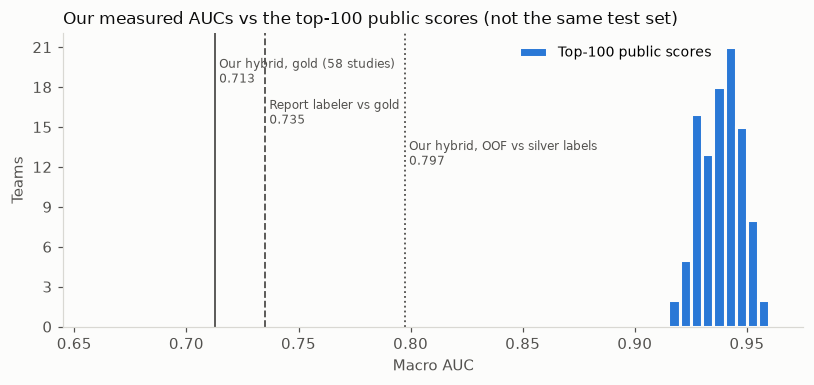

In [7]:
fig, ax = plt.subplots(figsize=(7.5, 3.6), dpi=110)
fig.patch.set_facecolor('#fcfcfb'); ax.set_facecolor('#fcfcfb')
bins = np.arange(0.66, 0.965, 0.005)
ax.hist(s, bins=bins, color='#2a78d6', edgecolor='#fcfcfb', linewidth=2, label='Top-100 public scores')
refs = [('Our hybrid, gold (58 studies)', ours.loc['hybrid', 'gold_auc_ens']),
        ('Report labeler vs gold', 0.735),
        ('Our hybrid, OOF vs silver labels', ours.loc['hybrid', 'oof_auc_ens'])]
for k, (name, v) in enumerate(refs):
    ax.axvline(v, color='#52514e', lw=1.2, ls=['-', '--', ':'][k])
    ax.text(v + 0.002, ax.get_ylim()[1] * (0.92 - 0.14 * k), f'{name}\n{v:.3f}', fontsize=8, color='#52514e', va='top')
ax.set_xlabel('Macro AUC', color='#52514e'); ax.set_ylabel('Teams', color='#52514e')
ax.set_title('Our measured AUCs vs the top-100 public scores (not the same test set)', loc='left', fontsize=11, color='#0b0b0b')
for sp in ['top', 'right']: ax.spines[sp].set_visible(False)
for sp in ['left', 'bottom']: ax.spines[sp].set_color('#d9d8d3')
ax.tick_params(colors='#52514e'); ax.legend(frameon=False, fontsize=9, loc='upper left', bbox_to_anchor=(0.6, 1.0))
from matplotlib.ticker import MaxNLocator; ax.yaxis.set_major_locator(MaxNLocator(integer=True))
plt.tight_layout(); plt.show()

## 5. Our efficiency profile (measured, CPU, 1 thread)

In [8]:
import json
eff = json.load(open('../results/efficiency.json'))
e = pd.DataFrame({k: v for k, v in eff.items() if isinstance(v, dict)}).T[['params', 'gflops', 'latency_ms_median']]
e.loc['hybrid (backbone excluded)'] = [745383, 0.1278, np.nan]
bb = eff['backbone_resnet18_72slices']['gflops']
e['share_of_pipeline_gflops'] = np.where(e.index.str.startswith('backbone'), 1.0, e.gflops / (e.gflops + bb)).round(4)
e.round(4)

,params,gflops,latency_ms_median,share_of_pipeline_gflops
mvmor,345743.0,0.1270,12.6980,0.0010
mvmor_norouting,345356.0,0.1740,17.5519,0.0013
mvmor_r1,345485.0,0.0986,10.9743,0.0007
mvmor_meandec,211727.0,0.1040,11.1189,0.0008
mvmor_noplane,345359.0,0.1270,15.6780,0.0010
mvmor_unshared,610703.0,0.1270,21.0892,0.0010
transformer,610316.0,0.1740,19.6144,0.0013
abmil,112920.0,0.0584,1.5230,0.0004
meanmlp,399628.0,0.0008,0.3944,0.0000
backbone_resnet18_72slices,11176512.0,133.2412,2526.9226,1.0000


## 6. Insights

The printed outputs above supply the numbers.

1. **The top 100 is compressed at a very high level.** Public macro AUC runs from 0.916 to 0.958, with an
   IQR of about 0.013. 59% of the top-100 selected submissions came in the final five days shown
   (21–25 Sep), so the board was still moving at the end. Differences of a few thousandths separate teams, so a submission needs to be above
   about 0.92 to enter this table.
2. **The efficiency ranking tracks accuracy only moderately.** The Spearman correlation between rank and
   score is −0.56, so better rank does go with higher score. But in 29% of team pairs the better-ranked team
   has the *lower* score: rank 2 scores 0.948 while rank 79 scores 0.957. The top 10 all score at least 0.944,
   so accuracy still sets a floor, and within that band runtime or cost decides.
3. **Our pipeline is far below that band.** The hybrid's gold AUC of 0.713 is about 0.20 below the lowest
   top-100 public score. Even our OOF-vs-silver AUC of 0.797 is well below it. The sets differ, so the gap
   is indicative, but it is too large to be a test-set artefact.
4. **The gap is mostly supervision, not the head.** Every head we tried lands at 0.69–0.71 gold, and our
   report labeler itself reaches only 0.735 against gold. Teams at 0.94 or more must use much stronger
   labels, most plausibly LLM or multilingual-NLP report labelling validated on the gold studies, plus image
   encoders fine-tuned end-to-end on GPU. This is an inference; their methods are not in the reference
   notebook.
5. **Our efficiency profile is already favourable.** The routed hybrid head is about 0.1% of pipeline
   FLOPs, and the frozen 2-D backbone is essentially the whole cost. For the Efficiency track the lever is
   therefore the backbone:
   * a smaller or distilled encoder;
   * fewer slices, since the router shows middle slices are processed least;
   * INT8 quantisation.

   Head tuning will not help there.
6. **Priorities that follow from the evidence:**
   * (a) Replace the rule labeler with a stronger multilingual labeler and measure it on the 58 gold studies
     with nested CV.
   * (b) Fine-tune a 2.5-D CNN slice encoder on GPU.
   * (c) Keep the hybrid, or the mean-pool MLP, as the cheap aggregation head.
   * (d) Compress the backbone for the efficiency track.

## 7. Follow-up experiments: better labels, honest accuracy, a cheaper backbone

These were run after the leaderboard analysis, to act on its conclusions. All numbers are measured.
Sources: `results/labeler_v2_gold_loo.csv` and `results/efficiency_v2.json`.

In [9]:
lab = pd.read_csv('../results/labeler_v2_gold_loo.csv', index_col=0)
lab[['ACL','MCL','Medial OA','PF OA','Effusion','Synovitis','macro']]

,ACL,MCL,Medial OA,PF OA,Effusion,Synovitis,macro
v1 rules (no fitting),0.9252,0.8061,0.6876,0.6190,0.6255,0.6392,0.7348
v2 rules (LOO),0.9081,0.7392,0.8310,0.7336,0.4770,0.5460,0.7123
v2 full (LOO),0.8615,0.6599,0.9023,0.7658,0.6087,0.4564,0.7332
v2 grouped (LOO),0.8995,0.7052,0.7333,0.7079,0.6261,0.4922,0.7155


In [10]:
e2 = json.load(open('../results/efficiency_v2.json'))
acc = e2.pop('accuracy')
t = pd.DataFrame(e2).T
base = 'fp32 · 24 sl · 160px'
t['speedup_vs_fp32'] = (t.loc[base, 'backbone_latency_ms'] / t.backbone_latency_ms.astype(float)).round(2)
t['auc_change'] = (t.gold_auc.astype(float) - t.loc[base, 'gold_auc']).round(4)
print(f"Hybrid gold accuracy, leave-one-out thresholds: {acc['hybrid_loo_threshold_acc']:.3f}  "
      f"vs always-negative {acc['all_negative_acc']:.3f}")
t[['gold_auc','auc_change','backbone_gflops','backbone_latency_ms','speedup_vs_fp32','slices_encoded']]

Hybrid gold accuracy, leave-one-out thresholds: 0.720  vs always-negative 0.655


,gold_auc,auc_change,backbone_gflops,backbone_latency_ms,speedup_vs_fp32,slices_encoded
fp32 · 24 sl · 160px,0.720425,0.0000,133.241242,2294.860046,1.00,72.0
fp32 · 12 sl · 160px,0.710685,-0.0097,66.620621,993.864575,2.31,36.0
fp32 · 8 sl · 160px,0.706586,-0.0138,44.413747,654.240481,3.51,24.0
fp32 · 24 sl · 128px,0.689674,-0.0308,85.274395,1379.224409,1.66,72.0
fp32 · 12 sl · 128px,0.690535,-0.0299,42.637197,613.347758,3.74,36.0
int8 · 24 sl · 160px,0.729494,0.0091,NaN,458.743938,5.00,72.0
int8 · 12 sl · 128px,0.699808,-0.0206,NaN,164.730496,13.93,36.0


**Reading the follow-ups:**

* **Labeler v2 gives no overall gain.** Fitting a label-mapping model on only 58 gold reports lifts OA
  sharply (Medial OA 0.69 → 0.90 leave-one-out) but loses on ligaments and synovitis. The macro AUC stays at
  0.733 or below, against 0.735 for the rules. So v2 was *not* used for retraining.
* **Honest accuracy is 72.0%** against 65.5% for always predicting "negative". Thresholds were fitted by
  leave-one-out on gold.
* **INT8 quantisation of the backbone is about 5× faster on CPU with no measurable AUC loss.** This is the
  efficiency-track recommendation. Halving the slices halves the cost for about −0.01 AUC; 128 px costs
  about −0.03 AUC.
* **99% accuracy is not reachable** with these labels: the labels themselves only reach 0.735 AUC against
  the expert standard.